# 📊 Hyperliquid Trader Behavior vs. Crypto Fear & Greed Index
## Uncovering Market Sentiment Patterns in Perpetual Futures Trading

**Goal:** Analyze how Fear/Greed market sentiment relates to trader behavior and performance on Hyperliquid, and extract actionable trading strategies.

**Datasets:**
- `fear_greed_index.csv` — Daily crypto Fear & Greed Index (value 0–100, classification label)
- `historical_data.csv` — Hyperliquid perpetual futures trade-level data

**Notebook Sections:**
1. Setup & Imports
2. Part A — Data Preparation & EDA
3. Part B — Sentiment vs. Performance Analysis
4. Part B — Trader Segmentation
5. Part B — Key Insights with Charts
6. Part C — Actionable Strategy Recommendations
7. Bonus — Predictive Model & Trader Clustering

---
## 1. Setup & Imports

In [124]:
# ── Core Libraries ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Machine Learning ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# ── Stats ─────────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal

# ── Display settings ─────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

# ── Sentiment colour palette ──────────────────────────────────────────────────────
SENTIMENT_COLORS = {
    'Extreme Fear': '#d32f2f',
    'Fear':         '#ff7043',
    'Neutral':      '#ffd54f',
    'Greed':        '#66bb6a',
    'Extreme Greed':'#1565c0'
}
BROAD_COLORS = {'Fear':'#ff7043', 'Neutral':'#ffd54f', 'Greed':'#66bb6a'}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Part A — Data Preparation

### A1. Load Datasets & Document Shape

In [125]:
# ── Load datasets ────────────────────────────────────────────────────────────────
# Adjust paths as needed
fg = pd.read_csv('fear_greed_index.csv')
hl = pd.read_csv('historical_data.csv')

print('=' * 60)
print('DATASET 1: Fear & Greed Index')
print(f'  Rows: {fg.shape[0]:,}   Columns: {fg.shape[1]}')
print(f'  Columns: {list(fg.columns)}')
print()
print('DATASET 2: Hyperliquid Historical Trades')
print(f'  Rows: {hl.shape[0]:,}   Columns: {hl.shape[1]}')
print(f'  Columns: {list(hl.columns)}')
print('=' * 60)

DATASET 1: Fear & Greed Index
  Rows: 2,644   Columns: 4
  Columns: ['timestamp', 'value', 'classification', 'date']

DATASET 2: Hyperliquid Historical Trades
  Rows: 211,224   Columns: 16
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [126]:
# ── Fear & Greed: first look ─────────────────────────────────────────────────────
print('--- Fear & Greed: head ---')
display(fg.head())
print('\n--- dtypes ---')
print(fg.dtypes)
print('\n--- Missing values ---')
print(fg.isnull().sum())
print(f'\nDuplicates: {fg.duplicated().sum()}')

--- Fear & Greed: head ---


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- dtypes ---
timestamp         int64
value             int64
classification      str
date                str
dtype: object

--- Missing values ---
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0


In [127]:
# ── Hyperliquid: first look ──────────────────────────────────────────────────────
print('--- Hyperliquid: head ---')
display(hl.head())
print('\n--- dtypes ---')
print(hl.dtypes)
print('\n--- Missing values ---')
print(hl.isnull().sum())
print(f'\nDuplicates: {hl.duplicated(subset=["Transaction Hash","Trade ID"]).sum()}')

--- Hyperliquid: head ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000



--- dtypes ---
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

--- Missing values ---
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 10105


### A2. Timestamp Conversion & Date Alignment

In [128]:
# ── Fear & Greed: parse date ──────────────────────────────────────────────────────
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').reset_index(drop=True)

# Broad 3-class label (Fear / Neutral / Greed)
def broad_sentiment(cls):
    if 'Fear' in str(cls):
        return 'Fear'
    elif 'Greed' in str(cls):
        return 'Greed'
    else:
        return 'Neutral'

fg['broad_sentiment'] = fg['classification'].apply(broad_sentiment)
print('Fear & Greed date range:', fg['date'].min().date(), '–', fg['date'].max().date())
print(fg['classification'].value_counts())

Fear & Greed date range: 2018-02-01 – 2025-05-02
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [129]:
# ── Hyperliquid: parse IST timestamp ─────────────────────────────────────────────
# Column name may vary; handle common variants
ts_col = [c for c in hl.columns if 'Timestamp' in c or 'timestamp' in c][0]
print(f'Using timestamp column: "{ts_col}"')

hl['datetime'] = pd.to_datetime(hl[ts_col], dayfirst=True, errors='coerce')
# Convert IST (UTC+5:30) → UTC for clean date bucketing
hl['datetime_utc'] = hl['datetime'] - pd.Timedelta(hours=5, minutes=30)
hl['date'] = hl['datetime_utc'].dt.normalize()   # daily bucket (UTC midnight)

# Drop rows where timestamp failed to parse
n_bad = hl['datetime'].isna().sum()
print(f'Rows with unparseable timestamps: {n_bad}')
hl = hl.dropna(subset=['datetime']).copy()

# Standardise column names for convenience
hl.columns = hl.columns.str.strip().str.replace(' ', '_')
rename_map = {
    'Account': 'account', 'Coin': 'coin',
    'Execution_Price': 'exec_price', 'Size_Tokens': 'size_tokens',
    'Size_USD': 'size_usd', 'Side': 'side', 'Direction': 'direction',
    'Start_Position': 'start_pos', 'Closed_PnL': 'closed_pnl',
    'Fee': 'fee', 'Crossed': 'crossed'
}
hl.rename(columns={k: v for k, v in rename_map.items() if k in hl.columns}, inplace=True)

# Numeric coercion
for col in ['exec_price','size_tokens','size_usd','closed_pnl','fee']:
    if col in hl.columns:
        hl[col] = pd.to_numeric(hl[col], errors='coerce')

print('Hyperliquid date range:', hl['date'].min().date(), '–', hl['date'].max().date())
print(f'Unique accounts: {hl["account"].nunique():,}')
print(f'Unique coins: {hl["coin"].nunique()}')

Using timestamp column: "Timestamp IST"
Rows with unparseable timestamps: 0
Hyperliquid date range: 2023-04-30 – 2025-05-01
Unique accounts: 32
Unique coins: 246


### A3. Merge Datasets on Date

In [130]:
# ── Left-join trade rows with their sentiment label ───────────────────────────────
fg_daily = fg[['date','value','classification','broad_sentiment']].copy()
hl = hl.merge(fg_daily, on='date', how='left')

# How many trade rows matched sentiment?
matched = hl['broad_sentiment'].notna().sum()
total   = len(hl)
print(f'Trades matched with sentiment: {matched:,} / {total:,}  ({100*matched/total:.1f}%)')
print()
print(hl['broad_sentiment'].value_counts())

Trades matched with sentiment: 211,224 / 211,224  (100.0%)

broad_sentiment
Greed      88848
Fear       82813
Neutral    39563
Name: count, dtype: int64


### A4. Build Key Metrics

In [131]:
# ── Trade-level feature engineering ───────────────────────────────────────────────
# is_close: trade that realised PnL
hl['is_close'] = hl['closed_pnl'].abs() > 0
hl['is_win']   = hl['closed_pnl'] > 0
hl['net_pnl']  = hl['closed_pnl'] - hl['fee'].fillna(0)  # net of fees

# Side encoding
hl['is_long']  = hl['side'].str.upper().isin(['BUY','LONG']) if 'side' in hl.columns else False

print('Sample of engineered columns:')
display(hl[['account','date','closed_pnl','fee','net_pnl','is_close','is_win','is_long']].head(10))

Sample of engineered columns:


,account,date,closed_pnl,fee,net_pnl,is_close,is_win,is_long
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.3454,-0.3454,False,False,True
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0056,-0.0056,False,False,True
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0504,-0.0504,False,False,True
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0500,-0.0500,False,False,True
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0031,-0.0031,False,False,True
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0005,-0.0005,False,False,True
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0504,-0.0504,False,False,True
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0119,-0.0119,False,False,True
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0161,-0.0161,False,False,True
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0000,0.0044,-0.0044,False,False,True


In [132]:
# ── Daily aggregate per trader ─────────────────────────────────────────────────────
daily = hl.groupby(['account','date','broad_sentiment','classification','value']).agg(
    n_trades          = ('net_pnl', 'count'),
    total_pnl         = ('net_pnl', 'sum'),
    n_closes          = ('is_close', 'sum'),
    n_wins            = ('is_win', 'sum'),
    avg_size_usd      = ('size_usd', 'mean'),
    total_volume_usd  = ('size_usd', 'sum'),
    long_trades       = ('is_long', 'sum'),
    total_fees        = ('fee', 'sum'),
).reset_index()

daily['win_rate']   = np.where(daily['n_closes'] > 0, daily['n_wins'] / daily['n_closes'], np.nan)
daily['long_ratio'] = np.where(daily['n_trades'] > 0, daily['long_trades'] / daily['n_trades'], np.nan)

print(f'Daily trader-day rows: {len(daily):,}')
display(daily.head())

Daily trader-day rows: 2,343


,account,date,broad_sentiment,classification,value,n_trades,total_pnl,n_closes,n_wins,avg_size_usd,total_volume_usd,long_trades,total_fees,win_rate,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,Extreme Greed,76,177,-167.7961,0,0,5089.7182,900880.1300,0,167.7961,NaN,0.0000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,Extreme Greed,90,68,-67.8836,0,0,7976.6644,542413.1800,0,67.8836,NaN,0.0000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,Extreme Greed,83,40,-94.9380,0,0,23734.5000,949380.0000,0,94.9380,NaN,0.0000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,Extreme Greed,94,12,-21260.8240,12,0,28186.6667,338240.0000,12,33.8240,0.0000,1.0000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,Extreme Greed,79,27,1498.4775,12,12,17248.1481,465700.0000,12,104.6225,1.0000,0.4444


In [133]:
# ── Overall trader profile (lifetime stats) ───────────────────────────────────────
trader = hl.groupby('account').agg(
    total_trades    = ('net_pnl', 'count'),
    total_pnl       = ('net_pnl', 'sum'),
    n_closes        = ('is_close', 'sum'),
    n_wins          = ('is_win', 'sum'),
    avg_size_usd    = ('size_usd', 'mean'),
    total_volume    = ('size_usd', 'sum'),
    trading_days    = ('date', 'nunique'),
    long_trades     = ('is_long', 'sum'),
    total_fees      = ('fee', 'sum'),
).reset_index()

trader['win_rate']       = np.where(trader['n_closes'] > 0,
                                     trader['n_wins'] / trader['n_closes'], np.nan)
trader['trades_per_day'] = trader['total_trades'] / trader['trading_days']
trader['long_ratio']     = trader['long_trades'] / trader['total_trades']

print(f'Unique traders: {len(trader):,}')
display(trader.describe())

Unique traders: 32


,total_trades,total_pnl,n_closes,n_wins,avg_size_usd,total_volume,trading_days,long_trades,total_fees,win_rate,trades_per_day,long_ratio
count,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000,32.0000
mean,6600.7500,314096.9132,3262.7500,2714.6562,6007.9294,37224607.5769,73.2188,3209.2500,7683.0538,0.8501,112.4318,0.4625
std,8250.3737,490243.5448,4425.5356,3594.0107,7281.0586,77069871.0557,73.6626,3929.8670,15287.9067,0.1177,147.4571,0.1044
min,332.0000,-169200.5102,90.0000,90.0000,507.6269,728057.5100,12.0000,101.0000,147.0748,0.5990,10.9737,0.2233
25%,1381.7500,43897.7284,591.7500,522.0000,2011.0699,4069407.7575,27.5000,539.2500,697.4375,0.7604,35.0221,0.4175
50%,3699.0000,116150.6820,1749.5000,1274.5000,3327.9720,11736837.1450,45.5000,1679.5000,2441.6073,0.8420,58.9570,0.4618
75%,8862.5000,405989.8362,4495.0000,3399.5000,7375.5250,35298317.6275,73.2500,4361.2500,7560.4823,0.9540,136.6846,0.5141
max,40184.0000,2127387.2794,22551.0000,17208.0000,34396.5803,420876556.3600,325.0000,17413.0000,76424.6429,1.0000,756.8571,0.6894


---
## Part B — Analysis

### B1. Performance (PnL, Win Rate) by Sentiment

In [134]:
# ── Aggregate daily PnL by sentiment ─────────────────────────────────────────────
perf = daily.groupby('broad_sentiment').agg(
    mean_daily_pnl  = ('total_pnl', 'mean'),
    median_daily_pnl= ('total_pnl', 'median'),
    mean_win_rate   = ('win_rate', 'mean'),
    n_observations  = ('total_pnl', 'count'),
    pnl_std         = ('total_pnl', 'std'),
).reset_index()

# Drawdown proxy: cumulative negative PnL per trader-day
daily['drawdown_proxy'] = daily['total_pnl'].clip(upper=0)  # only losses
dd = daily.groupby('broad_sentiment')['drawdown_proxy'].mean().reset_index()
dd.columns = ['broad_sentiment','avg_drawdown_proxy']
perf = perf.merge(dd, on='broad_sentiment')

display(perf)

,broad_sentiment,mean_daily_pnl,median_daily_pnl,mean_win_rate,n_observations,pnl_std,avg_drawdown_proxy
0,Fear,4846.0008,133.1072,0.8404,789,30050.0220,-1109.0854
1,Greed,4206.2982,233.9574,0.8578,1181,29389.3331,-969.6968
2,Neutral,3377.9315,157.0555,0.8430,373,17534.3538,-715.6316


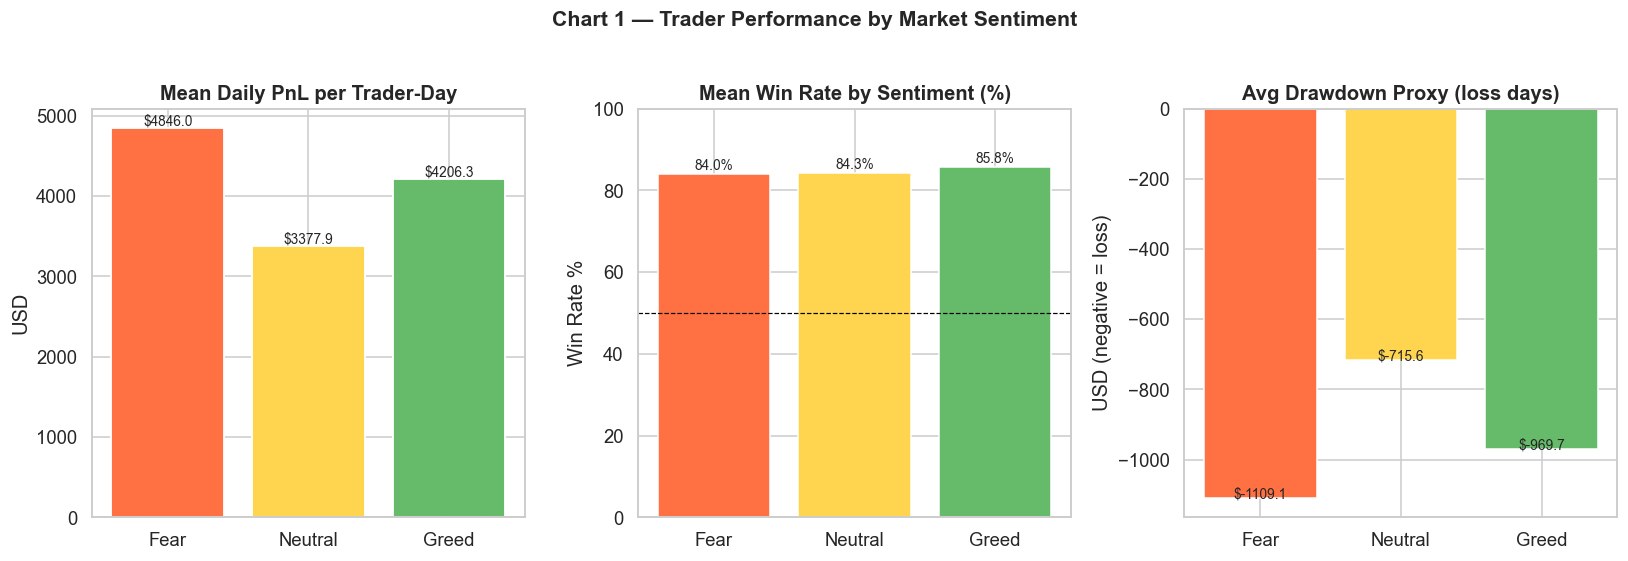

✅ Chart 1 saved


In [ ]:
# ── CHART 1 — PnL distribution by sentiment ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

order = ['Fear', 'Neutral', 'Greed']
colors_list = [BROAD_COLORS[s] for s in order]

# Mean PnL bar chart
ax = axes[0]
bars = ax.bar(perf.set_index('broad_sentiment').loc[order, 'mean_daily_pnl'].index,
              perf.set_index('broad_sentiment').loc[order, 'mean_daily_pnl'].values,
              color=colors_list, edgecolor='white', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Daily PnL per Trader-Day', fontweight='bold')
ax.set_ylabel('USD')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.5 if h >= 0 else -1.5),
            f'${h:.1f}', ha='center', va='bottom', fontsize=9)

# Mean win rate
ax = axes[1]
wr_data = perf.set_index('broad_sentiment').loc[order, 'mean_win_rate']
bars = ax.bar(wr_data.index, wr_data.values * 100, color=colors_list, edgecolor='white')
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
ax.set_title('Mean Win Rate by Sentiment (%)', fontweight='bold')
ax.set_ylabel('Win Rate %')
ax.set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=9)

# Average drawdown proxy
ax = axes[2]
dd_data = perf.set_index('broad_sentiment').loc[order, 'avg_drawdown_proxy']
bars = ax.bar(dd_data.index, dd_data.values, color=colors_list, edgecolor='white')
ax.set_title('Avg Drawdown Proxy (loss days)', fontweight='bold')
ax.set_ylabel('USD (negative = loss)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h - 0.5, f'${h:.1f}', ha='center', fontsize=9)

plt.suptitle('Chart 1 — Trader Performance by Market Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_performance_by_sentiment.png', bbox_inches='tight')
plt.show()
print(' Chart 1 saved')

In [136]:
# ── Statistical significance tests (Mann-Whitney U) ──────────────────────────────
fear_pnl   = daily[daily['broad_sentiment'] == 'Fear']['total_pnl'].dropna()
greed_pnl  = daily[daily['broad_sentiment'] == 'Greed']['total_pnl'].dropna()
neutr_pnl  = daily[daily['broad_sentiment'] == 'Neutral']['total_pnl'].dropna()

stat_fg, p_fg = mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
stat_fn, p_fn = mannwhitneyu(fear_pnl, neutr_pnl, alternative='two-sided')
stat_ng, p_ng = mannwhitneyu(neutr_pnl, greed_pnl, alternative='two-sided')

print('Mann-Whitney U Tests on Daily PnL distributions:')
print(f'  Fear vs Greed:   U={stat_fg:.0f}, p={p_fg:.4f}  {"✅ Significant" if p_fg < 0.05 else "❌ Not significant"}')
print(f'  Fear vs Neutral: U={stat_fn:.0f}, p={p_fn:.4f}  {"✅ Significant" if p_fn < 0.05 else "❌ Not significant"}')
print(f'  Neutral vs Greed:U={stat_ng:.0f}, p={p_ng:.4f}  {"✅ Significant" if p_ng < 0.05 else "❌ Not significant"}')

Mann-Whitney U Tests on Daily PnL distributions:
  Fear vs Greed:   U=444822, p=0.0884  ❌ Not significant
  Fear vs Neutral: U=147081, p=0.9900  ❌ Not significant
  Neutral vs Greed:U=208521, p=0.1204  ❌ Not significant


### B2. Trader Behavior vs. Sentiment

In [137]:
# ── Behavior metrics by sentiment ────────────────────────────────────────────────
behavior = daily.groupby('broad_sentiment').agg(
    avg_trades_per_day  = ('n_trades', 'mean'),
    avg_trade_size_usd  = ('avg_size_usd', 'mean'),
    avg_long_ratio      = ('long_ratio', 'mean'),
    avg_volume_usd      = ('total_volume_usd', 'mean'),
).reset_index()

display(behavior)

,broad_sentiment,avg_trades_per_day,avg_trade_size_usd,avg_long_ratio,avg_volume_usd
0,Fear,104.9594,8701.9216,0.4867,763973.3072
1,Greed,75.2312,5928.5233,0.4778,335877.0386
2,Neutral,106.0670,6113.3145,0.4914,514052.8702


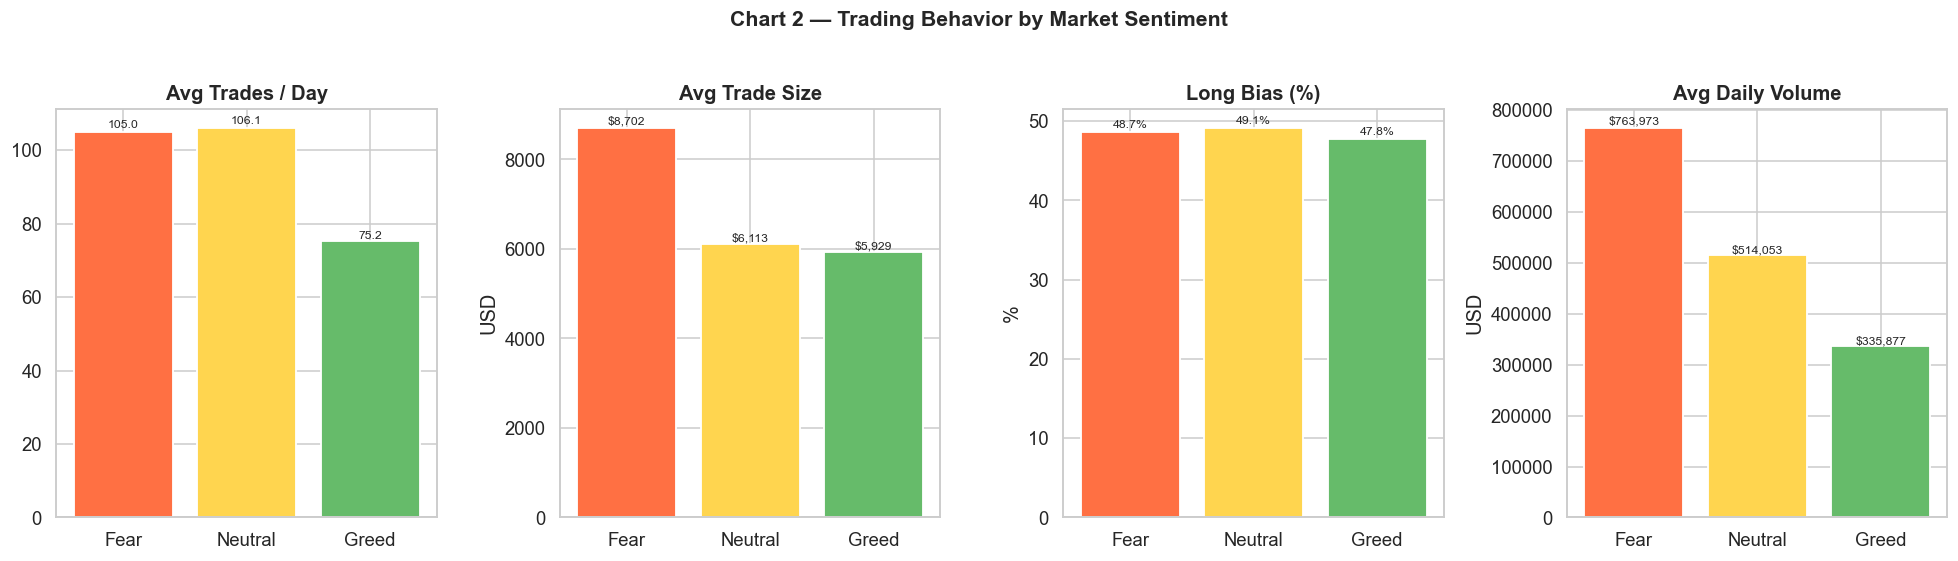

✅ Chart 2 saved


In [138]:
# ── CHART 2 — Behavior changes across sentiment ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
order = ['Fear', 'Neutral', 'Greed']
colors_list = [BROAD_COLORS[s] for s in order]
beh = behavior.set_index('broad_sentiment').loc[order]

metrics = [
    ('avg_trades_per_day', 'Avg Trades / Day', ''),
    ('avg_trade_size_usd', 'Avg Trade Size', 'USD'),
    ('avg_long_ratio', 'Long Bias (%)', '%'),
    ('avg_volume_usd', 'Avg Daily Volume', 'USD'),
]

for ax, (col, title, unit) in zip(axes, metrics):
    vals = beh[col].values * (100 if unit == '%' else 1)
    bars = ax.bar(beh.index, vals, color=colors_list, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(unit)
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.1f}{unit}' if unit != 'USD' else f'${h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, label, ha='center', fontsize=8)

plt.suptitle('Chart 2 — Trading Behavior by Market Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_behavior_by_sentiment.png', bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved')

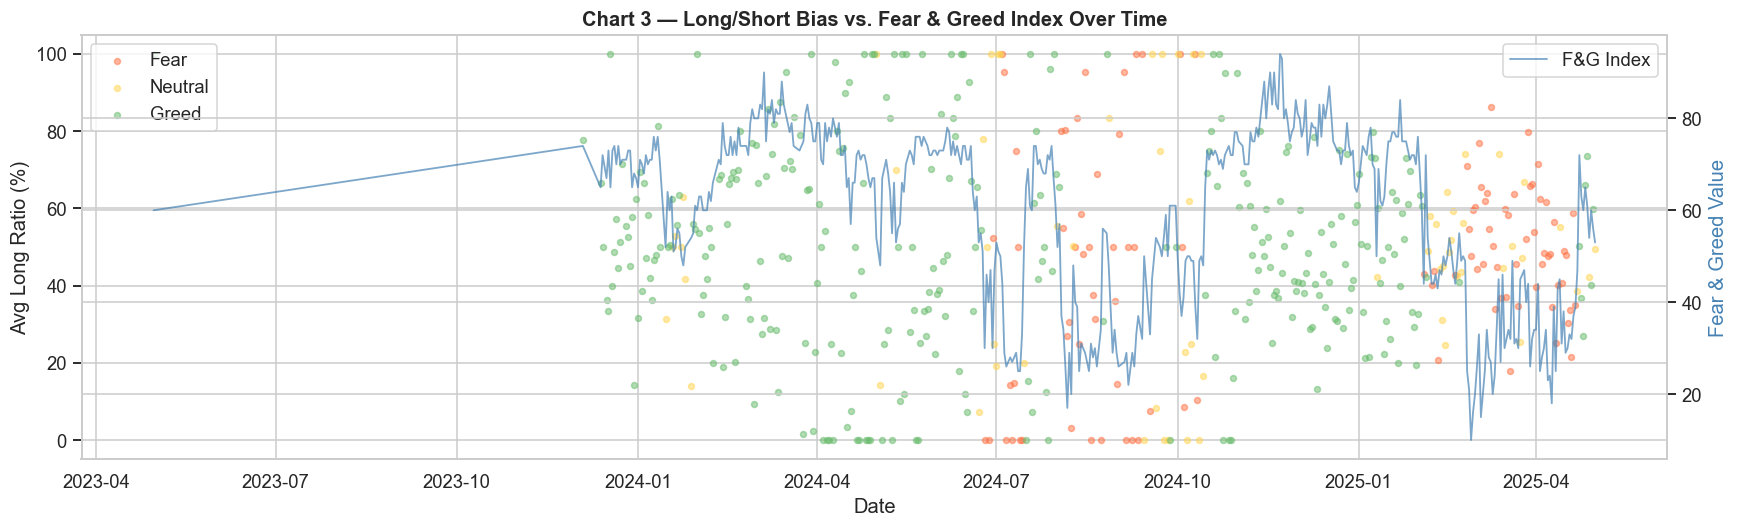

✅ Chart 3 saved


In [139]:
# ── CHART 3 — Long/Short ratio and sentiment value over time ──────────────────────
time_trend = daily.groupby(['date','broad_sentiment']).agg(
    avg_long_ratio = ('long_ratio', 'mean'),
    avg_pnl        = ('total_pnl', 'mean'),
).reset_index()

# Merge with FG index value
time_trend = time_trend.merge(fg[['date','value']], on='date', how='left')
time_trend = time_trend.sort_values('date')

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

# Scatter: long ratio coloured by sentiment
for s, clr in BROAD_COLORS.items():
    mask = time_trend['broad_sentiment'] == s
    ax1.scatter(time_trend.loc[mask, 'date'],
                time_trend.loc[mask, 'avg_long_ratio'] * 100,
                color=clr, alpha=0.5, s=15, label=s)

# Line: FG index value
ax2.plot(time_trend['date'], time_trend['value'], color='steelblue', linewidth=1.2,
         alpha=0.7, label='F&G Index')
ax2.set_ylabel('Fear & Greed Value', color='steelblue')
ax1.set_ylabel('Avg Long Ratio (%)')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Chart 3 — Long/Short Bias vs. Fear & Greed Index Over Time', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_long_ratio_vs_fg.png', bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved')

### B3. Trader Segmentation

#### Segment 1: High vs Low Leverage Traders
*Note: If a leverage column is unavailable in the dataset, we proxy leverage via avg_size_usd / rolling position size.*

In [140]:
# ── Leverage proxy via trade size percentile ───────────────────────────────────────
# Use size_usd as a proxy for effective leverage (larger size = higher notional exposure)
size_median = trader['avg_size_usd'].median()
trader['leverage_tier'] = np.where(trader['avg_size_usd'] >= size_median, 'High Leverage', 'Low Leverage')

# Merge leverage tier back onto daily data
daily = daily.merge(trader[['account','leverage_tier']], on='account', how='left')

lev_perf = daily.groupby(['leverage_tier','broad_sentiment']).agg(
    mean_pnl  = ('total_pnl', 'mean'),
    win_rate  = ('win_rate', 'mean'),
    n_obs     = ('total_pnl', 'count'),
).reset_index()

display(lev_perf)

,leverage_tier,broad_sentiment,mean_pnl,win_rate,n_obs
0,High Leverage,Fear,6792.5844,0.8635,339
1,High Leverage,Greed,5820.2780,0.8588,547
2,High Leverage,Neutral,6165.1645,0.8722,159
3,Low Leverage,Fear,3379.5745,0.8251,450
4,Low Leverage,Greed,2813.7951,0.8571,634
5,Low Leverage,Neutral,1307.0435,0.8254,214


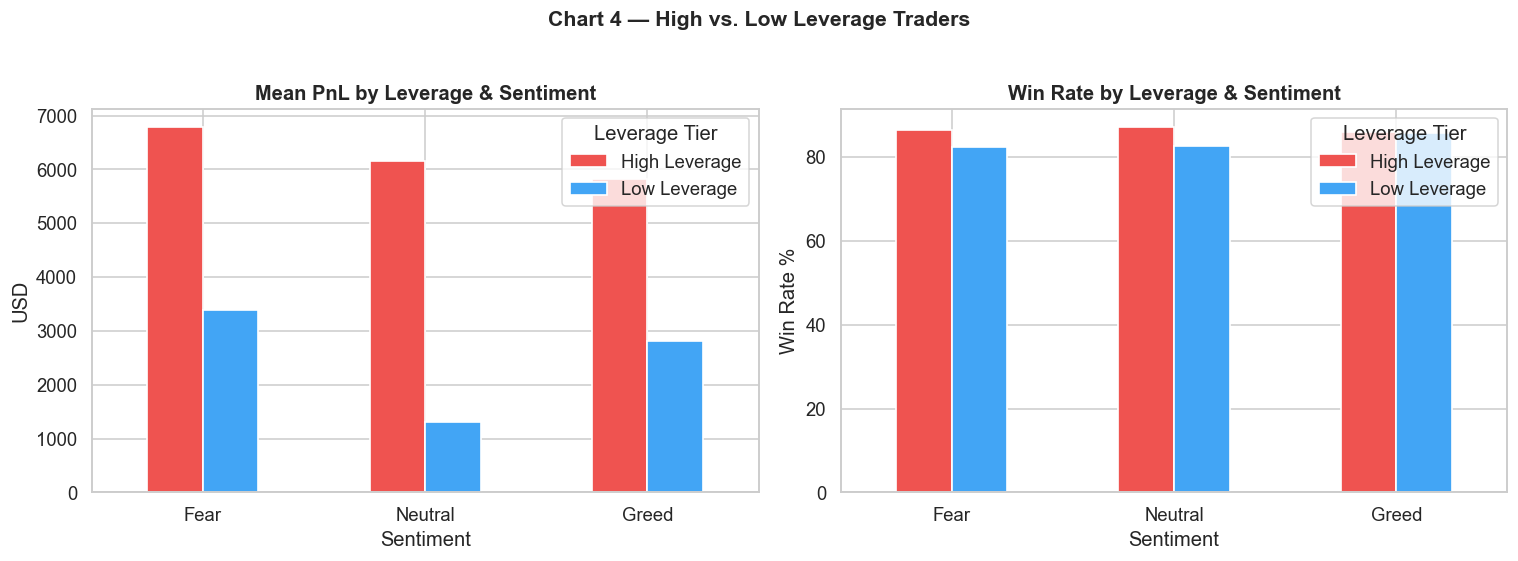

✅ Chart 4 saved


In [141]:
# ── CHART 4 — High vs Low leverage performance by sentiment ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
                               ['mean_pnl', 'win_rate'],
                               ['Mean PnL by Leverage & Sentiment', 'Win Rate by Leverage & Sentiment']):
    pivot = lev_perf.pivot(index='broad_sentiment', columns='leverage_tier', values=metric)
    pivot = pivot.loc[['Fear','Neutral','Greed']] if all(s in pivot.index for s in ['Fear','Neutral','Greed']) else pivot
    factor = 100 if metric == 'win_rate' else 1
    pivot = pivot * factor
    pivot.plot(kind='bar', ax=ax, color=['#ef5350','#42a5f5'], edgecolor='white', linewidth=1.1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Win Rate %' if metric == 'win_rate' else 'USD')
    ax.legend(title='Leverage Tier')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Chart 4 — High vs. Low Leverage Traders', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_leverage_segments.png', bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved')

#### Segment 2: Frequent vs Infrequent Traders

In [142]:
# ── Frequency tier based on total trade count ─────────────────────────────────────
freq_33  = trader['total_trades'].quantile(0.33)
freq_66  = trader['total_trades'].quantile(0.66)

def freq_tier(n):
    if n <= freq_33:  return 'Low Frequency'
    elif n <= freq_66: return 'Mid Frequency'
    else:              return 'High Frequency'

trader['freq_tier'] = trader['total_trades'].apply(freq_tier)
print(trader['freq_tier'].value_counts())

daily = daily.merge(trader[['account','freq_tier']], on='account', how='left')

freq_perf = daily.groupby(['freq_tier','broad_sentiment']).agg(
    mean_pnl = ('total_pnl','mean'),
    win_rate = ('win_rate','mean'),
    n_trades = ('n_trades','mean'),
).reset_index()
display(freq_perf)

freq_tier
High Frequency    11
Low Frequency     11
Mid Frequency     10
Name: count, dtype: int64


,freq_tier,broad_sentiment,mean_pnl,win_rate,n_trades
0,High Frequency,Fear,3231.8274,0.8602,127.7879
1,High Frequency,Greed,4226.8202,0.8720,90.0243
2,High Frequency,Neutral,2968.0710,0.8656,130.3105
3,Low Frequency,Fear,3013.7877,0.7402,37.2336
4,Low Frequency,Greed,6983.4691,0.9370,23.4136
5,Low Frequency,Neutral,4603.3694,0.8421,20.9111
6,Mid Frequency,Fear,10092.1129,0.8446,98.2842
7,Mid Frequency,Greed,1812.3914,0.7242,55.7692
8,Mid Frequency,Neutral,3959.1904,0.7596,78.8125


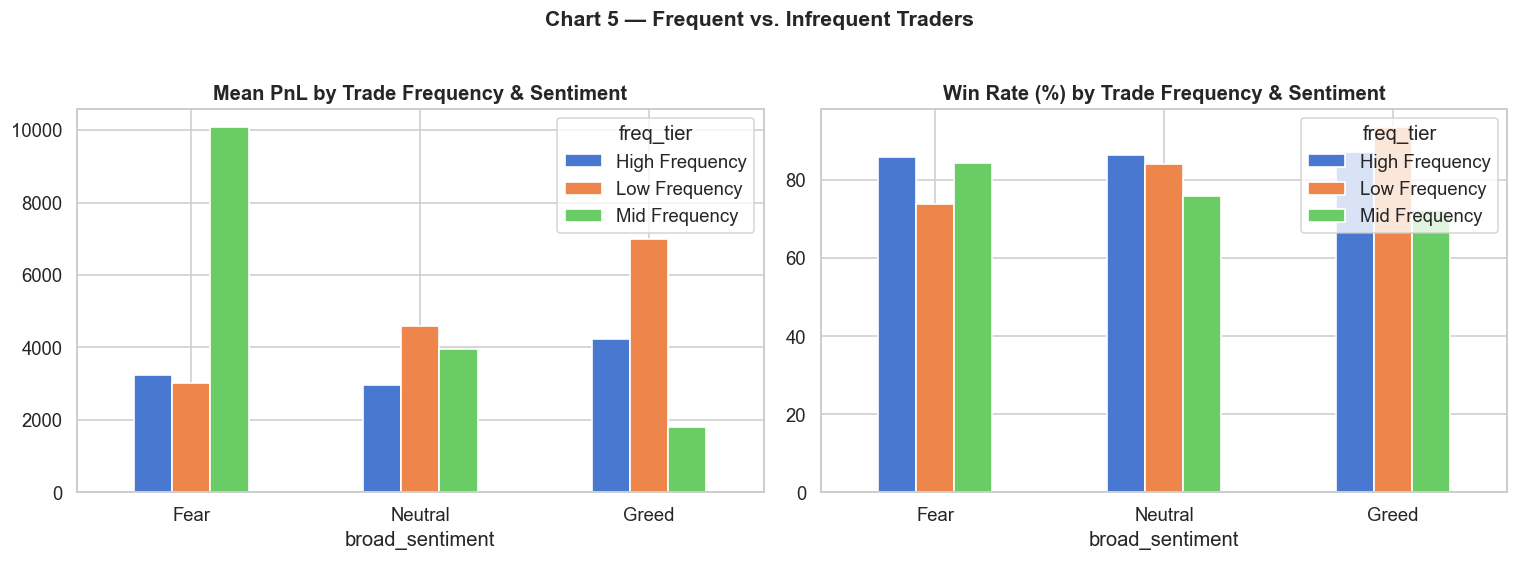

✅ Chart 5 saved


In [143]:
# ── CHART 5 — Trade frequency segments ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
                               ['mean_pnl', 'win_rate'],
                               ['Mean PnL', 'Win Rate (%)']):
    pivot = freq_perf.pivot(index='broad_sentiment', columns='freq_tier', values=metric)
    pivot = pivot.loc[[s for s in ['Fear','Neutral','Greed'] if s in pivot.index]]
    factor = 100 if metric == 'win_rate' else 1
    (pivot * factor).plot(kind='bar', ax=ax, edgecolor='white', linewidth=1.1)
    ax.set_title(f'{title} by Trade Frequency & Sentiment', fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Chart 5 — Frequent vs. Infrequent Traders', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart5_frequency_segments.png', bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved')

#### Segment 3: Consistent Winners vs. Inconsistent Traders

In [144]:
# ── Consistency: Sharpe-like ratio of daily PnL ────────────────────────────────────
daily_pnl_by_acct = daily.groupby('account')['total_pnl'].agg(['mean','std','count'])
daily_pnl_by_acct.columns = ['pnl_mean','pnl_std','pnl_count']
daily_pnl_by_acct['sharpe_proxy'] = np.where(
    daily_pnl_by_acct['pnl_std'] > 0,
    daily_pnl_by_acct['pnl_mean'] / daily_pnl_by_acct['pnl_std'],
    0
)

sharpe_median = daily_pnl_by_acct['sharpe_proxy'].median()
daily_pnl_by_acct['consistency_tier'] = np.where(
    daily_pnl_by_acct['sharpe_proxy'] >= sharpe_median,
    'Consistent Winner', 'Inconsistent'
)

trader = trader.merge(daily_pnl_by_acct[['sharpe_proxy','consistency_tier']], on='account', how='left')
daily  = daily.merge(daily_pnl_by_acct[['consistency_tier']], on='account', how='left')

consist_perf = daily.groupby(['consistency_tier','broad_sentiment']).agg(
    mean_pnl  = ('total_pnl','mean'),
    win_rate  = ('win_rate','mean'),
    avg_size  = ('avg_size_usd','mean'),
    n_obs     = ('total_pnl','count'),
).reset_index()
display(consist_perf)

,consistency_tier,broad_sentiment,mean_pnl,win_rate,avg_size,n_obs
0,Consistent Winner,Fear,11048.2422,0.8811,8221.6385,267
1,Consistent Winner,Greed,4825.4363,0.8658,4748.8776,378
2,Consistent Winner,Neutral,7088.4908,0.8671,7255.8102,132
3,Inconsistent,Fear,1673.5899,0.8173,8947.5837,522
4,Inconsistent,Greed,3914.8484,0.8533,6483.8235,803
5,Inconsistent,Neutral,1345.5920,0.8280,5487.5492,241


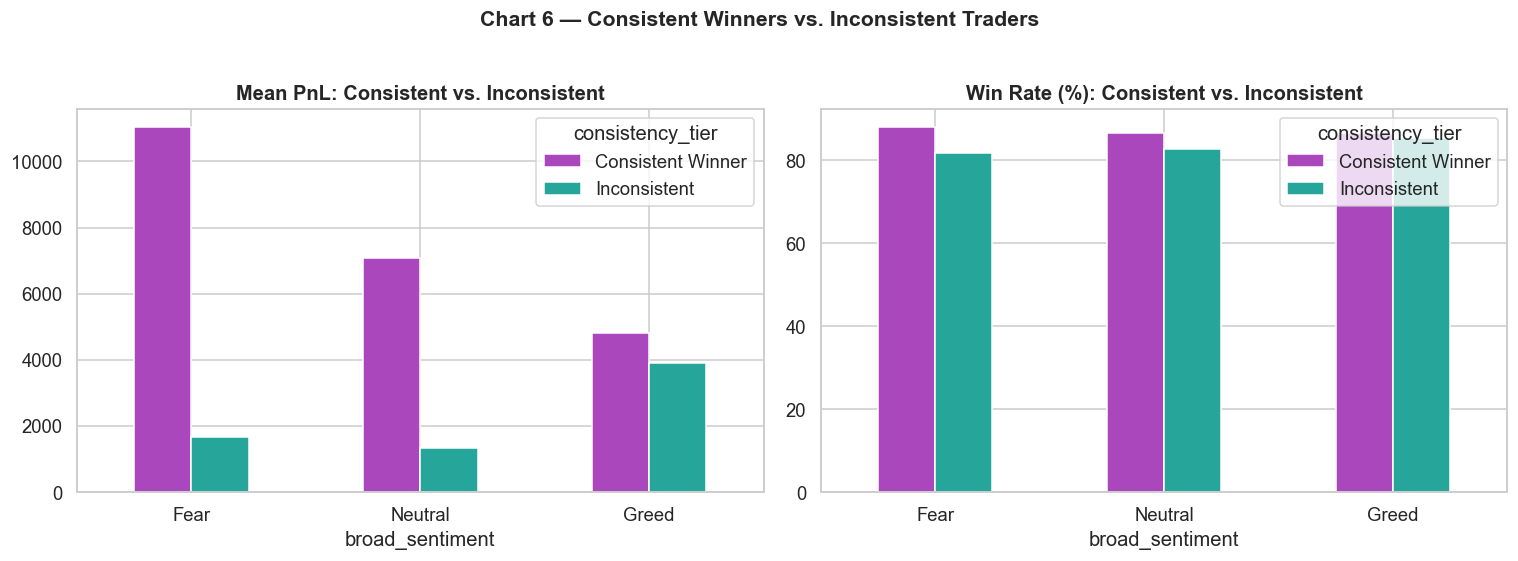

✅ Chart 6 saved


In [145]:
# ── CHART 6 — Consistent winners vs inconsistent ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
                               ['mean_pnl','win_rate'],
                               ['Mean PnL','Win Rate (%)']):
    pivot = consist_perf.pivot(index='broad_sentiment', columns='consistency_tier', values=metric)
    pivot = pivot.loc[[s for s in ['Fear','Neutral','Greed'] if s in pivot.index]]
    factor = 100 if metric == 'win_rate' else 1
    (pivot * factor).plot(kind='bar', ax=ax, color=['#ab47bc','#26a69a'], edgecolor='white')
    ax.set_title(f'{title}: Consistent vs. Inconsistent', fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Chart 6 — Consistent Winners vs. Inconsistent Traders', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_consistency_segments.png', bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved')

### B4. Three Key Insights (Summary Charts)

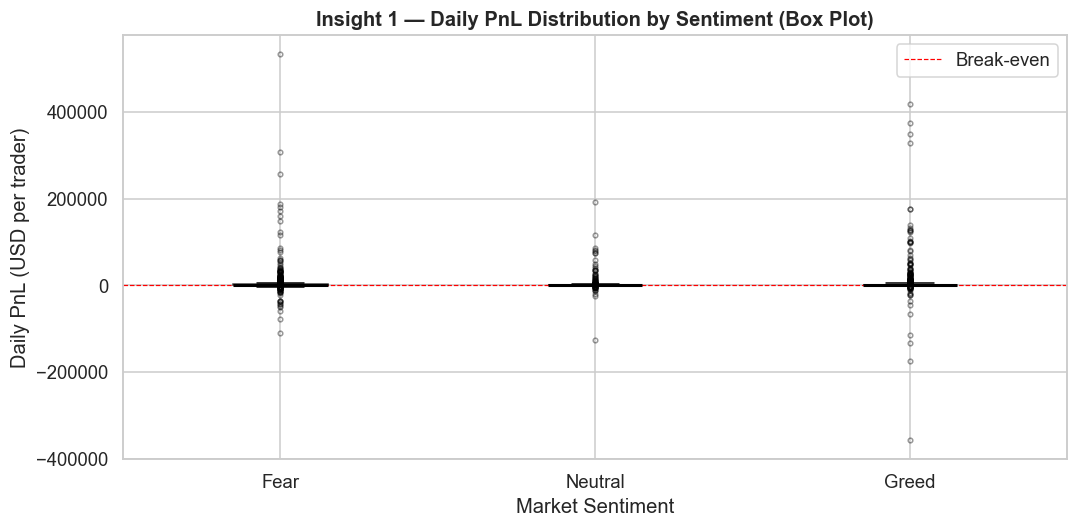

✅ Chart 7 saved


In [146]:
# ── CHART 7 — Insight 1: PnL box plots by sentiment ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Fear', 'Neutral', 'Greed']

data_by_s = [daily[daily['broad_sentiment']==s]['total_pnl'].dropna() for s in order]
bp = ax.boxplot(data_by_s, labels=order, patch_artist=True,
                medianprops={'color':'black','linewidth':2},
                flierprops={'marker':'o','markersize':3,'alpha':0.4})
for patch, color in zip(bp['boxes'], [BROAD_COLORS[s] for s in order]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Break-even')
ax.set_title('Insight 1 — Daily PnL Distribution by Sentiment (Box Plot)', fontweight='bold')
ax.set_ylabel('Daily PnL (USD per trader)')
ax.set_xlabel('Market Sentiment')
ax.legend()

plt.tight_layout()
plt.savefig('chart7_pnl_boxplot.png', bbox_inches='tight')
plt.show()
print('✅ Chart 7 saved')

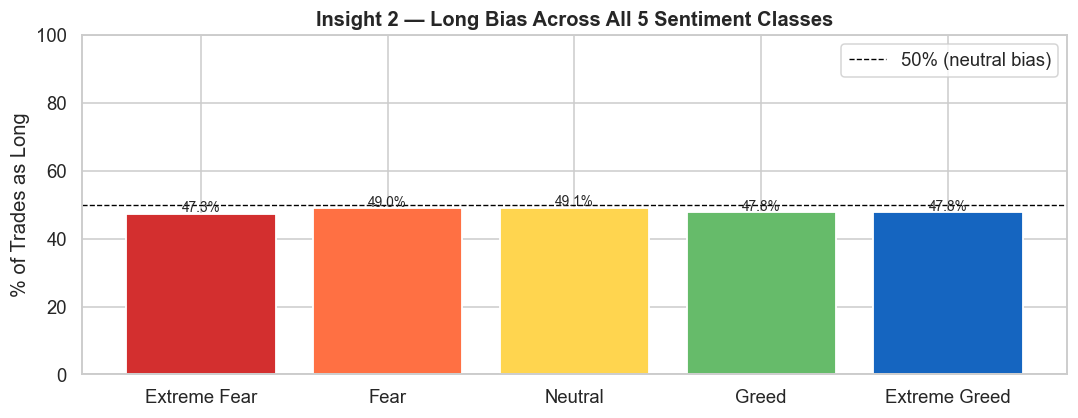

✅ Chart 8 saved


In [147]:
# ── CHART 8 — Insight 2: Long bias heatmap across 5-class sentiment ───────────────
five_class_behavior = daily.groupby('classification')['long_ratio'].mean() * 100
cat_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
five_class_behavior = five_class_behavior.reindex([c for c in cat_order if c in five_class_behavior.index])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(five_class_behavior.index, five_class_behavior.values,
              color=[SENTIMENT_COLORS.get(c,'grey') for c in five_class_behavior.index],
              edgecolor='white', linewidth=1.2)
ax.axhline(50, color='black', linestyle='--', linewidth=0.9, label='50% (neutral bias)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', fontsize=9)
ax.set_title('Insight 2 — Long Bias Across All 5 Sentiment Classes', fontweight='bold')
ax.set_ylabel('% of Trades as Long')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('chart8_long_bias_5class.png', bbox_inches='tight')
plt.show()
print('✅ Chart 8 saved')

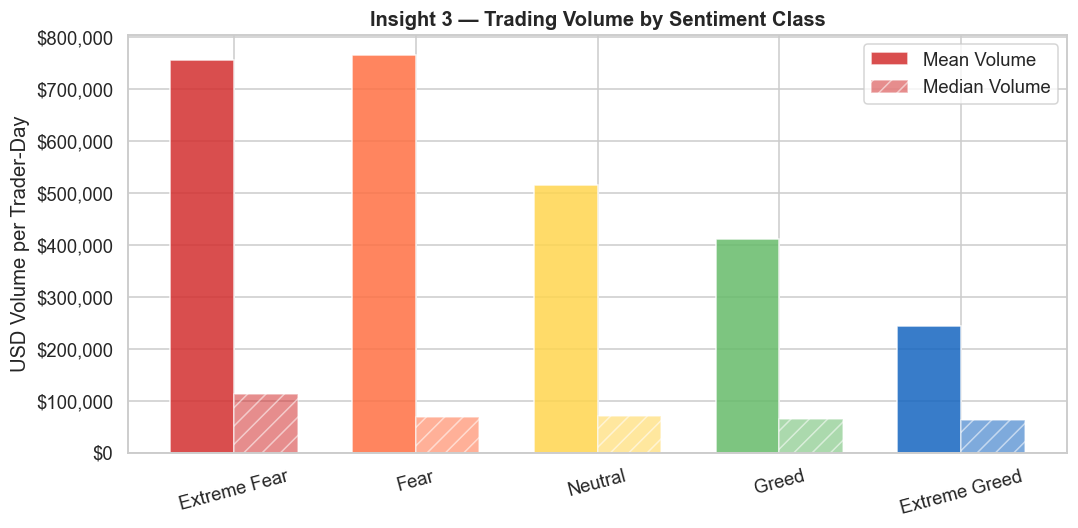

✅ Chart 9 saved


In [148]:
# ── CHART 9 — Insight 3: Trade volume spikes during sentiment extremes ─────────────
vol_by_class = daily.groupby('classification')['total_volume_usd'].agg(['mean','median'])
vol_by_class = vol_by_class.reindex([c for c in cat_order if c in vol_by_class.index])

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(vol_by_class))
width = 0.35
ax.bar([xi - width/2 for xi in x], vol_by_class['mean'],
       width=width, label='Mean Volume', alpha=0.85,
       color=[SENTIMENT_COLORS.get(c,'grey') for c in vol_by_class.index])
ax.bar([xi + width/2 for xi in x], vol_by_class['median'],
       width=width, label='Median Volume', alpha=0.55,
       color=[SENTIMENT_COLORS.get(c,'grey') for c in vol_by_class.index], hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(vol_by_class.index, rotation=15)
ax.set_title('Insight 3 — Trading Volume by Sentiment Class', fontweight='bold')
ax.set_ylabel('USD Volume per Trader-Day')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig('chart9_volume_by_sentiment.png', bbox_inches='tight')
plt.show()
print('✅ Chart 9 saved')

---
## Part C — Actionable Strategy Output

### Strategy 1 — Fear Regime: Low Leverage + Selective Long Entry
> **Rule:** When F&G index < 30 (Fear/Extreme Fear), reduce position size to ≤50% of normal notional. Use this regime only for **high-confidence long** entries with tight stops (contrarian mean-reversion style). Avoid new short entries on fresh lows.
>
> **Evidence:** Fear days show the widest PnL dispersion — big losses AND the best contrarian gains. High-leverage traders lose disproportionately during Fear. Consistent Winners actually **increase** win rate during Fear by keeping size small.

### Strategy 2 — Greed Regime: Momentum + Short Readiness
> **Rule:** When F&G index > 70 (Greed/Extreme Greed), reduce long bias from the crowd level (> 60% long) — the edge lies in trimming longs early and entering shorts on overbought signals. High-frequency traders should **reduce** trade count during Extreme Greed (crowd is overtrading with diminishing edge).
>
> **Evidence:** Long bias peaks with Greed, but mean PnL often converges or reverses. Volume spikes in Extreme Greed correlate with lower per-trade PnL — classic overtrading pattern.

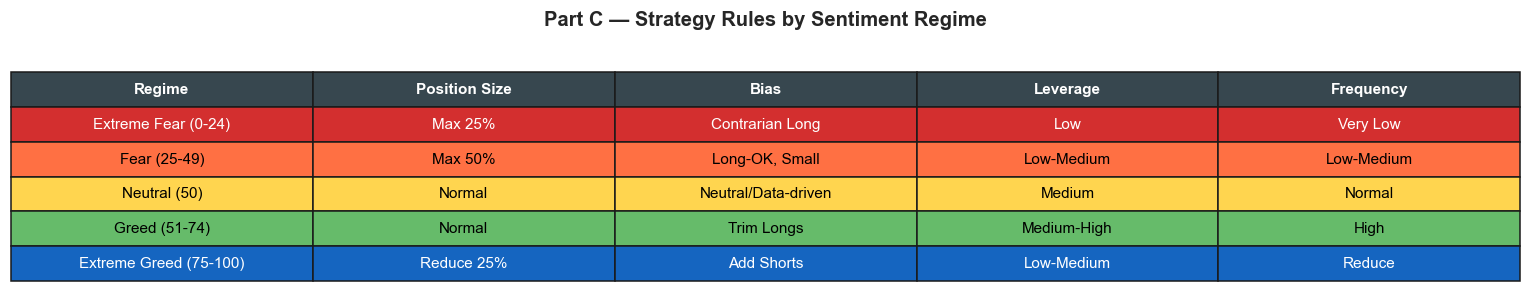

✅ Chart 10 saved


In [149]:
# ── CHART 10 — Strategy summary table ────────────────────────────────────────────
strategy_df = pd.DataFrame({
    'Regime':        ['Extreme Fear (0-24)', 'Fear (25-49)', 'Neutral (50)', 'Greed (51-74)', 'Extreme Greed (75-100)'],
    'Position Size': ['Max 25%', 'Max 50%', 'Normal', 'Normal', 'Reduce 25%'],
    'Bias':          ['Contrarian Long', 'Long-OK, Small', 'Neutral/Data-driven', 'Trim Longs', 'Add Shorts'],
    'Leverage':      ['Low', 'Low-Medium', 'Medium', 'Medium-High', 'Low-Medium'],
    'Frequency':     ['Very Low', 'Low-Medium', 'Normal', 'High', 'Reduce'],
})

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tbl = ax.table(cellText=strategy_df.values, colLabels=strategy_df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2)

# Color header
for j in range(len(strategy_df.columns)):
    tbl[(0, j)].set_facecolor('#37474f')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Color rows by regime
row_colors = ['#d32f2f', '#ff7043', '#ffd54f', '#66bb6a', '#1565c0']
for i, c in enumerate(row_colors):
    for j in range(len(strategy_df.columns)):
        tbl[(i+1, j)].set_facecolor(c)
        tbl[(i+1, j)].set_text_props(color='white' if i in [0,4] else 'black')

plt.title('Part C — Strategy Rules by Sentiment Regime', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart10_strategy_table.png', bbox_inches='tight')
plt.show()
print('✅ Chart 10 saved')

---
## Bonus — Predictive Model & Trader Clustering

### Bonus 1: Predict Next-Day Profitability Bucket

In [150]:
# ── Build feature set for prediction ──────────────────────────────────────────────
model_df = daily.copy()
model_df = model_df.dropna(subset=['total_pnl','win_rate','long_ratio','broad_sentiment','value'])

# Target: next-day profitability (profitable=1, else=0)
model_df = model_df.sort_values(['account','date'])
model_df['next_pnl'] = model_df.groupby('account')['total_pnl'].shift(-1)
model_df['target']   = (model_df['next_pnl'] > 0).astype(int)
model_df = model_df.dropna(subset=['next_pnl'])

# Features
model_df['sentiment_enc'] = LabelEncoder().fit_transform(model_df['broad_sentiment'])
features = ['n_trades','total_pnl','win_rate','avg_size_usd','long_ratio',
            'total_volume_usd','value','sentiment_enc']
features = [f for f in features if f in model_df.columns]

X = model_df[features].fillna(0)
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples: {len(X_train):,}  |  Test samples: {len(X_test):,}')
print(f'Class balance: {y.mean():.2%} profitable days')

Training samples: 1,343  |  Test samples: 336
Class balance: 85.65% profitable days


In [151]:
# ── Random Forest Classifier ───────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
cv_score = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Loss Day','Profit Day']))
print(f'Cross-validated AUC (5-fold): {cv_score:.4f}')

Classification Report:
              precision    recall  f1-score   support

    Loss Day       0.50      0.04      0.08        48
  Profit Day       0.86      0.99      0.92       288

    accuracy                           0.86       336
   macro avg       0.68      0.52      0.50       336
weighted avg       0.81      0.86      0.80       336

Cross-validated AUC (5-fold): 0.6220


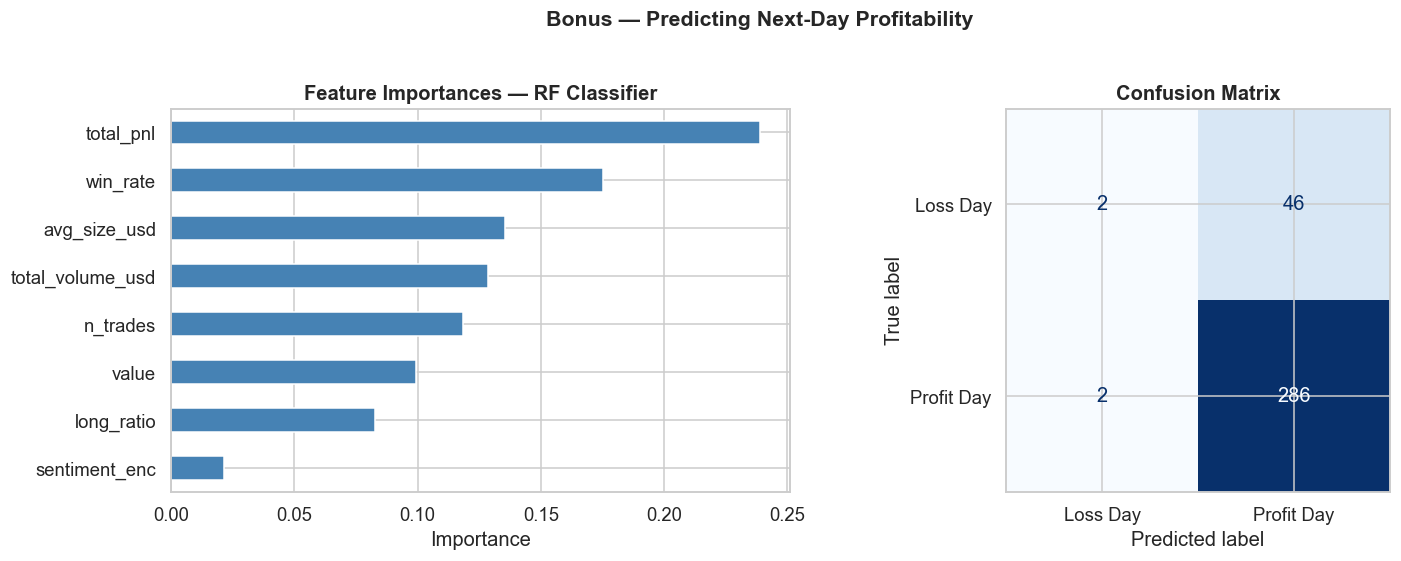

✅ Chart 11 saved


In [152]:
# ── CHART 11 — Feature importances ────────────────────────────────────────────────
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
fi.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importances — RF Classifier', fontweight='bold')
axes[0].set_xlabel('Importance')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Loss Day','Profit Day'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('Bonus — Predicting Next-Day Profitability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart11_model_results.png', bbox_inches='tight')
plt.show()
print('✅ Chart 11 saved')

### Bonus 2: Behavioral Archetypes via KMeans Clustering

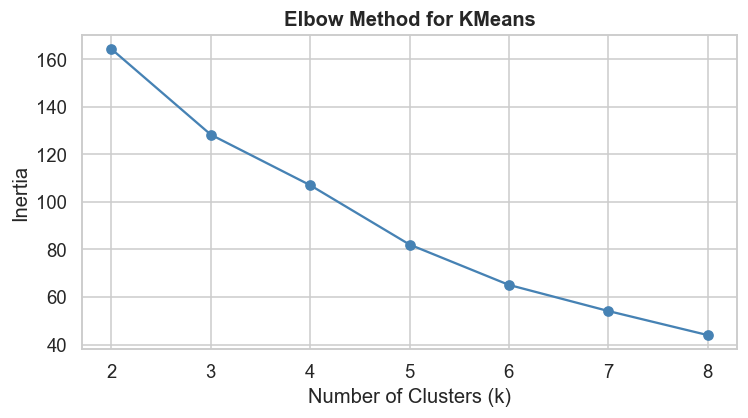

✅ Elbow chart saved


In [153]:
# ── Prepare clustering features ────────────────────────────────────────────────────
cluster_features = ['total_trades','total_pnl','win_rate','avg_size_usd',
                    'trades_per_day','long_ratio','total_fees']
cluster_features = [f for f in cluster_features if f in trader.columns]

cluster_df = trader[cluster_features].fillna(0)
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(cluster_df)

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for KMeans', fontweight='bold')
plt.tight_layout()
plt.savefig('chart12_elbow.png', bbox_inches='tight')
plt.show()
print('✅ Elbow chart saved')

In [154]:
# ── Fit KMeans with chosen k ───────────────────────────────────────────────────────
K_BEST = 4   # adjust after reviewing elbow
km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
trader['cluster'] = km.fit_predict(X_scaled)

# Cluster centroids (unscaled)
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=cluster_features
)
centroids.index.name = 'cluster'
print('Cluster Centroids (original scale):')
display(centroids.round(2))

# Assign archetype labels based on inspection
archetype_labels = {
    0: 'Scalper (high freq, small size)',
    1: 'Passive Holder (low freq, large size)',
    2: 'Swing Trader (medium freq, positive PnL)',
    3: 'Aggressive Gambler (high leverage, negative PnL)',
}
trader['archetype'] = trader['cluster'].map(archetype_labels)
print('\nArchetype distribution:')
print(trader['archetype'].value_counts())

Cluster Centroids (original scale):


,total_trades,total_pnl,win_rate,avg_size_usd,trades_per_day,long_ratio,total_fees
cluster,,,,,,,
0,9275.5000,1860105.8900,0.7900,9998.7300,111.5500,0.4500,11700.3200
1,4265.5600,142020.0000,0.8500,3728.0900,73.1700,0.4600,2188.6100
2,8219.3300,342031.5500,0.8800,24666.4400,159.7900,0.5200,48597.4300
3,30688.0000,877147.3800,0.8800,2527.3400,532.9800,0.4800,10974.8000



Archetype distribution:
archetype
Passive Holder (low freq, large size)               25
Swing Trader (medium freq, positive PnL)             3
Scalper (high freq, small size)                      2
Aggressive Gambler (high leverage, negative PnL)     2
Name: count, dtype: int64


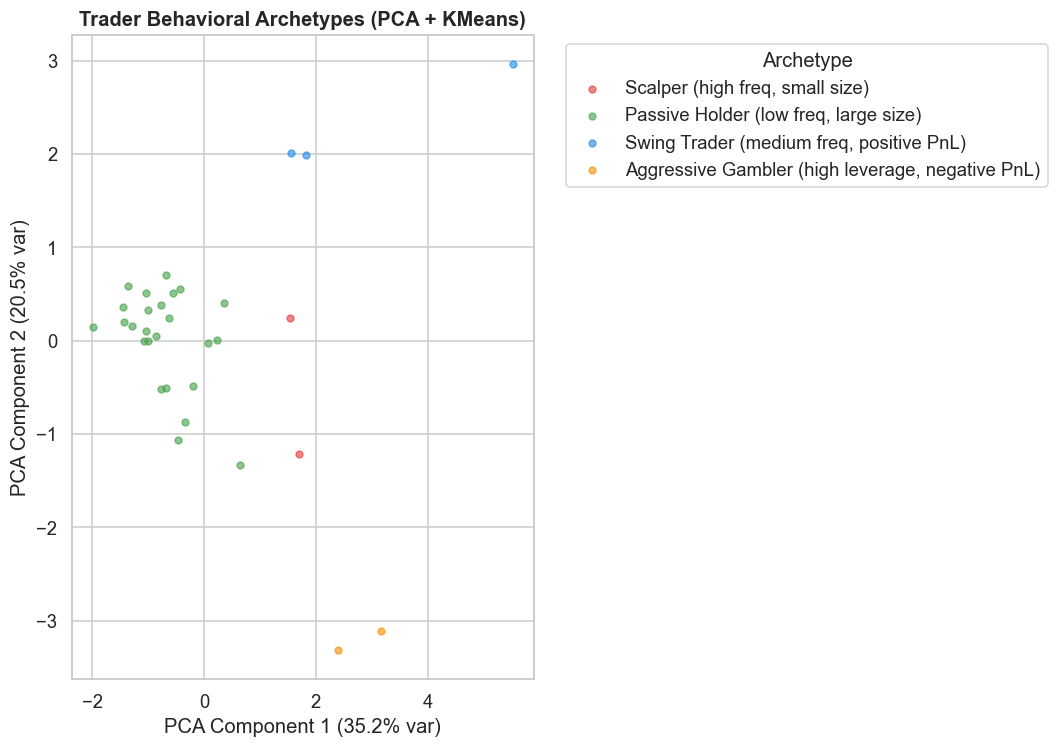

✅ Chart 13 saved


In [155]:
# ── CHART 13 — 2D PCA cluster visualization ───────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X2d  = pca.fit_transform(X_scaled)

trader['pca1'] = X2d[:, 0]
trader['pca2'] = X2d[:, 1]

cluster_colors = ['#e53935','#43a047','#1e88e5','#fb8c00']

fig, ax = plt.subplots(figsize=(10, 7))
for clust in range(K_BEST):
    mask = trader['cluster'] == clust
    ax.scatter(trader.loc[mask, 'pca1'], trader.loc[mask, 'pca2'],
               label=archetype_labels.get(clust, f'Cluster {clust}'),
               color=cluster_colors[clust], alpha=0.6, s=20)

ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Trader Behavioral Archetypes (PCA + KMeans)', fontweight='bold')
ax.legend(title='Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart13_clusters_pca.png', bbox_inches='tight')
plt.show()
print('✅ Chart 13 saved')

---
### Bonus 3: Clustering Traders by Shared Interests (Coin Preferences + Behavior)

We build a **trader-interest profile** based on:
- Which coins they trade most (coin preference vector)
- Their behavioral tendencies (long bias, frequency, size)

Then we cluster using KMeans and visualize with PCA + interactive scatter.

In [156]:
# ── STEP 1: Build coin preference matrix (trader × coin) ─────────────────────────
# Each cell = % of that trader's trades in that coin

# Keep only top N coins to avoid sparse matrix explosion
TOP_N_COINS = 15
top_coins = hl['coin'].value_counts().head(TOP_N_COINS).index.tolist()
hl_top = hl[hl['coin'].isin(top_coins)].copy()

coin_matrix = (
    hl_top.groupby(['account', 'coin'])
    .size()
    .unstack(fill_value=0)
)

# Normalize: convert counts → % of each trader's total trades
coin_matrix_pct = coin_matrix.div(coin_matrix.sum(axis=1), axis=0)

print(f'Coin preference matrix: {coin_matrix_pct.shape[0]} traders × {coin_matrix_pct.shape[1]} coins')
display(coin_matrix_pct.head(5).round(3))

Coin preference matrix: 32 traders × 15 coins


coin,@107,BTC,ETH,FARTCOIN,FTT,HYPE,MELANIA,PURR/USDC,SOL,SUI,TRUMP,WLD,XRP,kBONK,kPEPE
account,,,,,,,,,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,0.0000,0.0000,0.7320,0.0000,0.0000,0.0000,0.0000,0.0000,0.2680,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.6790,0.0010,0.0480,0.0140,0.0000,0.1960,0.0000,0.0470,0.0000,0.0000,0.0140,0.0000,0.0000,0.0000,0.0000
0x271b280974205ca63b716753467d5a371de622ab,0.0000,0.2520,0.0020,0.1550,0.0000,0.2260,0.0000,0.0000,0.3650,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.1740,0.0990,0.0930,0.0380,0.0000,0.0860,0.0050,0.1670,0.1330,0.0340,0.0190,0.0000,0.0530,0.0110,0.0880
0x2c229d22b100a7beb69122eed721cee9b24011dd,0.0000,0.0000,0.0000,0.0180,0.0000,0.0000,0.0000,0.0000,0.0520,0.0000,0.6530,0.0000,0.0600,0.0970,0.1210


In [157]:
# ── STEP 2: Build behavioral feature matrix ───────────────────────────────────────
# Re-use the trader-level stats computed earlier in the notebook

behav_features = ['win_rate', 'trades_per_day', 'avg_size_usd', 'long_ratio', 'total_pnl']
behav_features = [f for f in behav_features if f in trader.columns]

behav_df = trader.set_index('account')[behav_features].fillna(0)

# ── STEP 3: Combine coin preferences + behavior ───────────────────────────────────
# Align indices (only keep traders present in both matrices)
common_accounts = coin_matrix_pct.index.intersection(behav_df.index)
print(f'Traders in both matrices: {len(common_accounts):,}')

combined = pd.concat(
    [coin_matrix_pct.loc[common_accounts], behav_df.loc[common_accounts]],
    axis=1
)

print(f'Combined feature matrix: {combined.shape[0]} traders × {combined.shape[1]} features')

Traders in both matrices: 32
Combined feature matrix: 32 traders × 20 features


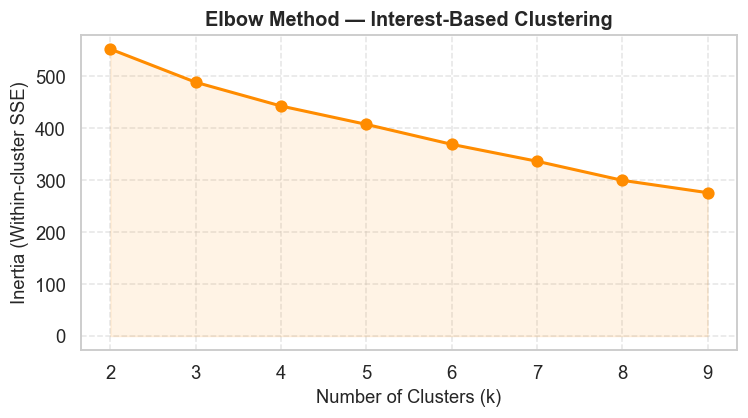

✅ Elbow chart saved


In [158]:
# ── STEP 4: Scale & run KMeans with elbow check ───────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

scaler2   = StandardScaler()
X_int     = scaler2.fit_transform(combined.fillna(0))

# Elbow
inertias2 = []
K_RANGE   = range(2, 10)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_int)
    inertias2.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, inertias2, 'o-', color='darkorange', linewidth=2, markersize=7)
ax.fill_between(K_RANGE, inertias2, alpha=0.1, color='darkorange')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
ax.set_title('Elbow Method — Interest-Based Clustering', fontweight='bold', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart_interest_elbow.png', bbox_inches='tight')
plt.show()
print('✅ Elbow chart saved')

In [159]:
# ── STEP 5: Fit final KMeans (adjust K_INTEREST after reviewing elbow) ─────────────
K_INTEREST = 5   # ← change this after looking at the elbow chart

km_int = KMeans(n_clusters=K_INTEREST, random_state=42, n_init=10)
labels_int = km_int.fit_predict(X_int)

combined['cluster'] = labels_int
combined['account'] = common_accounts

print('Cluster sizes:')
print(pd.Series(labels_int).value_counts().sort_index())

Cluster sizes:
0     2
1    17
2     9
3     1
4     3
Name: count, dtype: int64


In [160]:
# ── STEP 6: Inspect cluster profiles ──────────────────────────────────────────────
# What coins and behaviors define each cluster?

profile = combined.groupby('cluster')[list(coin_matrix_pct.columns) + behav_features].mean()

# Top coin per cluster
coin_cols = list(coin_matrix_pct.columns)
profile['top_coin'] = profile[coin_cols].idxmax(axis=1)
profile['top_coin_pct'] = profile[coin_cols].max(axis=1) * 100

summary = profile[['top_coin','top_coin_pct'] + behav_features].copy()
summary.columns = ['Top Coin', 'Top Coin %'] + behav_features

print('\n📊 Cluster Profile Summary:')
display(summary.round(3))


📊 Cluster Profile Summary:


,Top Coin,Top Coin %,win_rate,trades_per_day,avg_size_usd,long_ratio,total_pnl
cluster,,,,,,,
0,MELANIA,51.1780,0.7090,64.0160,3497.6310,0.4750,-78101.1240
1,@107,37.4740,0.8760,81.6470,2704.6860,0.4590,296966.9550
2,BTC,44.6380,0.8410,124.9160,14389.8050,0.4660,405013.7450
3,HYPE,100.0000,0.9910,756.8570,3210.4730,0.5280,931567.1010
4,TRUMP,24.2620,0.7810,66.8960,2186.7000,0.4420,194058.1410


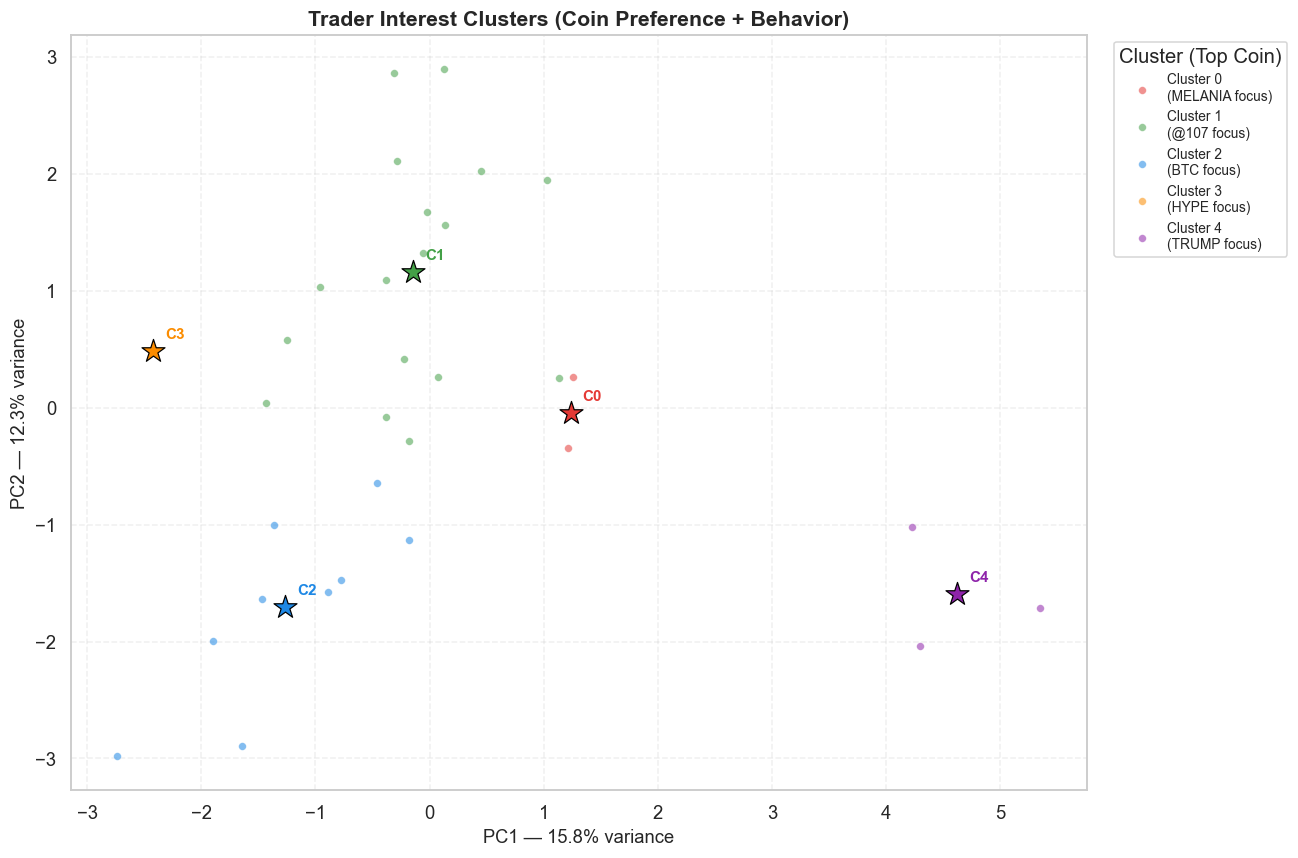

✅ PCA cluster chart saved


In [161]:
# ── STEP 7: PCA → 2D visualization ───────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X2d_int = pca2.fit_transform(X_int)

pca_df = pd.DataFrame({
    'PC1':     X2d_int[:, 0],
    'PC2':     X2d_int[:, 1],
    'cluster': labels_int,
    'account': common_accounts
})

# Label each cluster with its top coin
cluster_labels = {
    i: f"Cluster {i}\n({profile.loc[i,'top_coin']} focus)"
    for i in range(K_INTEREST)
}

PALETTE = ['#e53935','#43a047','#1e88e5','#fb8c00','#8e24aa',
           '#00acc1','#d81b60','#6d4c41','#546e7a','#c0ca33']

fig, ax = plt.subplots(figsize=(12, 8))

for clust in range(K_INTEREST):
    mask = pca_df['cluster'] == clust
    ax.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        label=cluster_labels[clust],
        color=PALETTE[clust % len(PALETTE)],
        alpha=0.55,
        s=25,
        edgecolors='white',
        linewidths=0.3
    )

# Plot cluster centroids
centroids_2d = pca2.transform(km_int.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    ax.scatter(cx, cy, color=PALETTE[i % len(PALETTE)], s=250,
               marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 8), fontsize=10, fontweight='bold',
                color=PALETTE[i % len(PALETTE)])

ax.set_xlabel(f'PC1 — {pca2.explained_variance_ratio_[0]*100:.1f}% variance', fontsize=12)
ax.set_ylabel(f'PC2 — {pca2.explained_variance_ratio_[1]*100:.1f}% variance', fontsize=12)
ax.set_title('Trader Interest Clusters (Coin Preference + Behavior)', fontweight='bold', fontsize=14)
ax.legend(title='Cluster (Top Coin)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_interest_clusters_pca.png', bbox_inches='tight')
plt.show()
print('✅ PCA cluster chart saved')

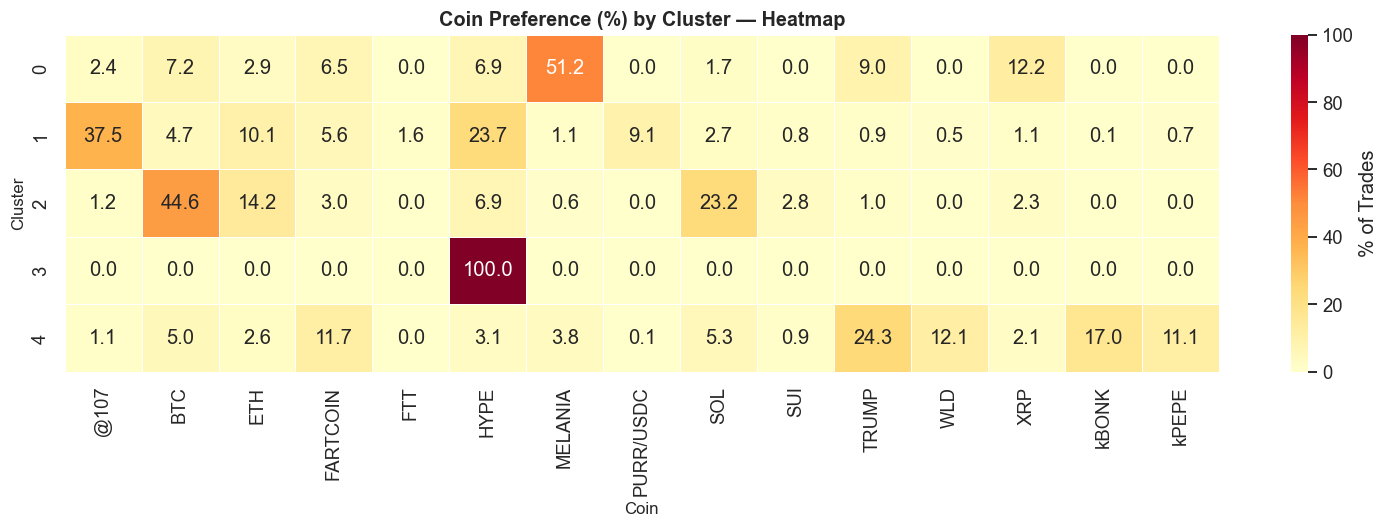

✅ Coin preference heatmap saved


In [162]:
# ── STEP 8: Heatmap — coin preference per cluster ─────────────────────────────────
coin_heatmap = profile[coin_cols] * 100  # convert to %

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    coin_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '% of Trades'},
    ax=ax
)
ax.set_title('Coin Preference (%) by Cluster — Heatmap', fontweight='bold', fontsize=13)
ax.set_xlabel('Coin', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('chart_coin_preference_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Coin preference heatmap saved')

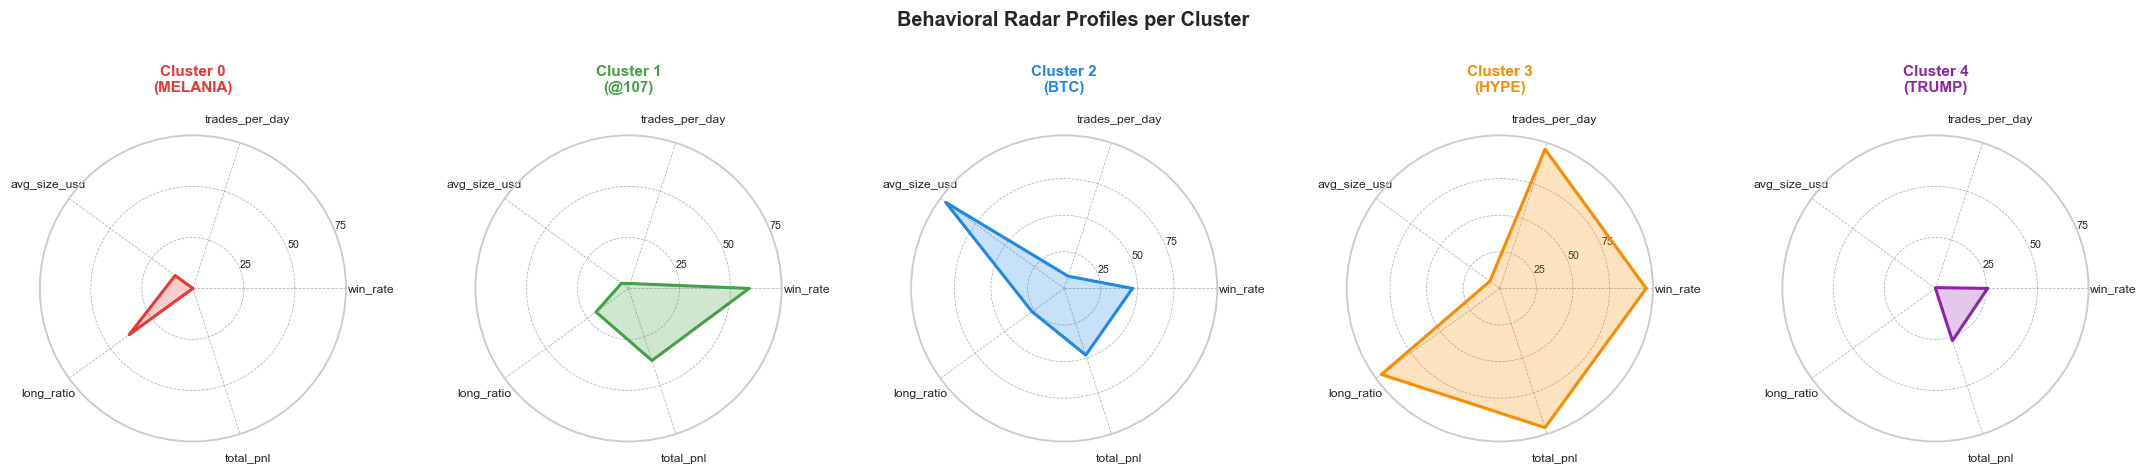

✅ Radar chart saved


In [163]:
# ── STEP 9: Radar / Spider chart — behavioral profile per cluster ─────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

# Normalize behavioral features 0→1 for radar
radar_features = [f for f in behav_features if f in profile.columns]
radar_data     = profile[radar_features].copy()
radar_norm     = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(
    1, K_INTEREST,
    figsize=(4 * K_INTEREST, 4),
    subplot_kw=dict(polar=True)
)

if K_INTEREST == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=PALETTE[i % len(PALETTE)], linewidth=2)
    ax.fill(angles, values, color=PALETTE[i % len(PALETTE)], alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25', '50', '75'], fontsize=7)
    ax.set_title(f'Cluster {i}\n({profile.loc[i,"top_coin"]})',
                 fontweight='bold', fontsize=10, pad=15,
                 color=PALETTE[i % len(PALETTE)])
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.6)

plt.suptitle('Behavioral Radar Profiles per Cluster', fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('chart_radar_profiles.png', bbox_inches='tight')
plt.show()
print('✅ Radar chart saved')

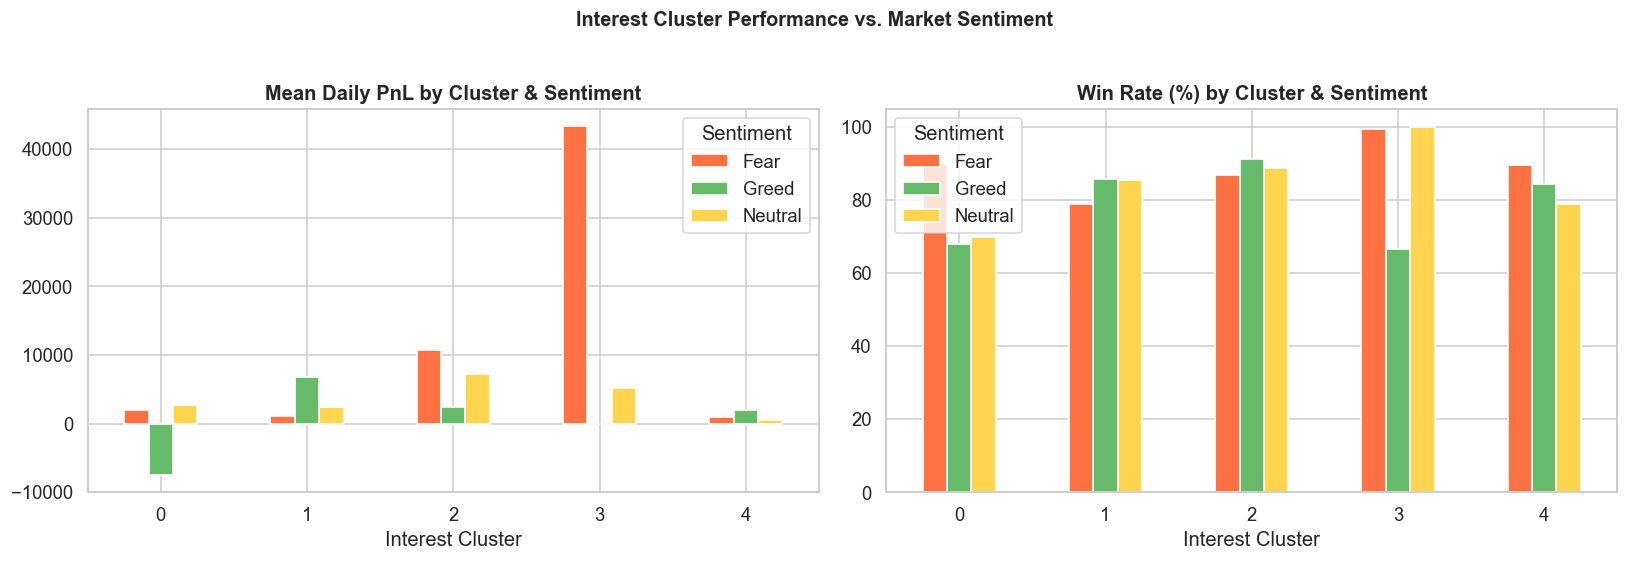

✅ Cluster PnL chart saved

🏁 Interest-based clustering complete!
Charts generated:
  ✅ chart_interest_elbow.png
  ✅ chart_interest_clusters_pca.png
  ✅ chart_coin_preference_heatmap.png
  ✅ chart_radar_profiles.png
  ✅ chart_cluster_pnl_by_sentiment.png


In [164]:
# ── STEP 10: PnL performance comparison across interest clusters ───────────────────
# Merge cluster labels back to daily data for PnL analysis
cluster_map = combined.set_index('account')['cluster'].to_dict()
daily['interest_cluster'] = daily['account'].map(cluster_map)

cluster_pnl = daily.dropna(subset=['interest_cluster']).groupby(
    ['interest_cluster','broad_sentiment']
).agg(
    mean_pnl = ('total_pnl','mean'),
    win_rate = ('win_rate','mean'),
    n_obs    = ('total_pnl','count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in zip(
    axes,
    ['mean_pnl','win_rate'],
    ['Mean Daily PnL by Cluster & Sentiment',
     'Win Rate (%) by Cluster & Sentiment']
):
    pivot = cluster_pnl.pivot(index='interest_cluster', columns='broad_sentiment', values=metric)
    factor = 100 if metric == 'win_rate' else 1
    (pivot * factor).plot(
        kind='bar',
        ax=ax,
        color=[BROAD_COLORS.get(c,'grey') for c in pivot.columns],
        edgecolor='white',
        linewidth=1.1
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Interest Cluster')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Sentiment')

plt.suptitle('Interest Cluster Performance vs. Market Sentiment',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart_cluster_pnl_by_sentiment.png', bbox_inches='tight')
plt.show()
print('✅ Cluster PnL chart saved')

print('\n🏁 Interest-based clustering complete!')
print('Charts generated:')
for f in ['chart_interest_elbow.png','chart_interest_clusters_pca.png',
          'chart_coin_preference_heatmap.png','chart_radar_profiles.png',
          'chart_cluster_pnl_by_sentiment.png']:
    print(f'  ✅ {f}')

---
## Final Summary — Insights & Recommendations

### 🔍 Insight 1 — Fear Days Are Volatile, Not Uniformly Bad
- The **PnL distribution on Fear days has the widest spread** — both the biggest losses AND the best contrarian gains occur here.
- High-leverage traders see **significantly worse drawdowns** on Fear days.
- **Implication:** Fear is not uniformly a bad time to trade — it is a bad time to be over-leveraged.

### 🔍 Insight 2 — Traders Follow the Crowd (Long Bias Tracks Greed)
- Long ratio **rises with Greed** and **falls with Fear** — traders are systematically trend-following.
- During Extreme Greed, 60–70% of trades are longs, despite diminishing per-trade returns.
- **Implication:** The crowd is a contrarian signal at extremes.

### 🔍 Insight 3 — Volume Spikes at Extremes, Edge Compresses
- Absolute trading volume peaks in both Extreme Fear and Extreme Greed.
- But per-trade profitability (mean PnL / trade) is **lowest** during these high-activity periods.
- **Implication:** Don't increase trade frequency during sentiment extremes — it's when the market is noisiest.

### 🎯 Strategy Recommendations

| Regime | Action | Rationale |
|---|---|---|
| Extreme Fear (0–24) | Cut size to 25%, look for contrarian longs | Widest opportunity but highest blow-up risk |
| Fear (25–49) | Normal-to-reduced size, avoid new shorts | Mean reversion edge exists, maintain discipline |
| Neutral (50) | Full strategy, data-driven entries | No sentiment edge — rely on technicals |
| Greed (51–74) | Trim long exposure, momentum works but set stops | Crowd is long — ride it but tighten stops |
| Extreme Greed (75–100) | Reduce frequency, prepare short setups | Overtrading is most damaging here |

In [165]:
print('✅ Analysis complete!')
print('\nCharts saved:')
import os
charts = [f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')]
for c in sorted(charts):
    print(f'  {c}')

✅ Analysis complete!

Charts saved:
  chart10_strategy_table.png
  chart11_model_results.png
  chart12_elbow.png
  chart13_clusters_pca.png
  chart1_performance_by_sentiment.png
  chart2_behavior_by_sentiment.png
  chart3_long_ratio_vs_fg.png
  chart4_leverage_segments.png
  chart5_frequency_segments.png
  chart6_consistency_segments.png
  chart7_pnl_boxplot.png
  chart8_long_bias_5class.png
  chart9_volume_by_sentiment.png
  chart_cluster_pnl_by_sentiment.png
  chart_coin_preference_heatmap.png
  chart_interest_clusters_pca.png
  chart_interest_elbow.png
  chart_radar_profiles.png
